### 3. Selección de métricas  

En este apartado nos centraremos en las métricas de clasificación.

Para comenzar, entrenar una **regressió logística**. A partir de esta, generar una serie de funciones para analizar los resultados.  

También se ha de elegir la métrica que se hará servir posteriormente para escoger el mejor modelo.  

**Preguntas:**  
-  ¿Cuál de las siguientes métricas se cree que es más adecuada para el problema? Justifíca. 
   - `accuracy_score`  
   - `f1_score`  
   - `average_precision_score`  
-  Antes de entrenar modelos, generar una suite de funciones para analizar gráficamente el rendimiento. 
   -  Mostrar la *Precision-Recall Curve* y la *ROC Curve*.  
   -  ¿Cuál es más relevante para su dataset? 
   -  Explicar con sus palabras la diferencia entre ambas.
-  Que muestra el [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)?  
   -  ¿Qué métrica elegirá para optimizar la clasificación en su caso?




In [2]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, average_precision_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc 
from sklearn.metrics import confusion_matrix, classification_report
from mapminer.miners import LandsatMiner
import seaborn as sns 


from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

In [3]:
# Cargar 
df = pd.read_csv('../data/dataset.csv')
df = df.sort_values(by='lat').reset_index(drop=True) 
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
# 2. Target
y = df['estado']
 
X = df.drop(columns=['id_campo', 'estado', 'lat', 'lon', 'fecha_captura', 'rango'], errors='ignore')
X = X.select_dtypes(include=[np.number])  
nombres_X = X.columns.tolist()  
 
limite = int(len(X) * 0.8)
x_train, x_test = X.iloc[:limite], X.iloc[limite:]
y_train, y_test = y.iloc[:limite], y.iloc[limite:]
 
medianas_train = x_train.median(numeric_only=True)
x_train = x_train.fillna(medianas_train)
x_test = x_test.fillna(medianas_train)
 
x_train = x_train.fillna(0)
x_test = x_test.fillna(0)
 
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train = pd.DataFrame(x_train_scaled, columns=X.columns)
x_test = pd.DataFrame(x_test_scaled, columns=X.columns)


---------------------------------------------
------------ SELECCIÓN DE MÉTRICAS ------------
---------------------------------------------

PRIMER PUNTO:
Accuracy: 0.8446
F1 Score (macro): 0.8463
Average Precision (macro): 0.9324
--- Análisis ROC ---


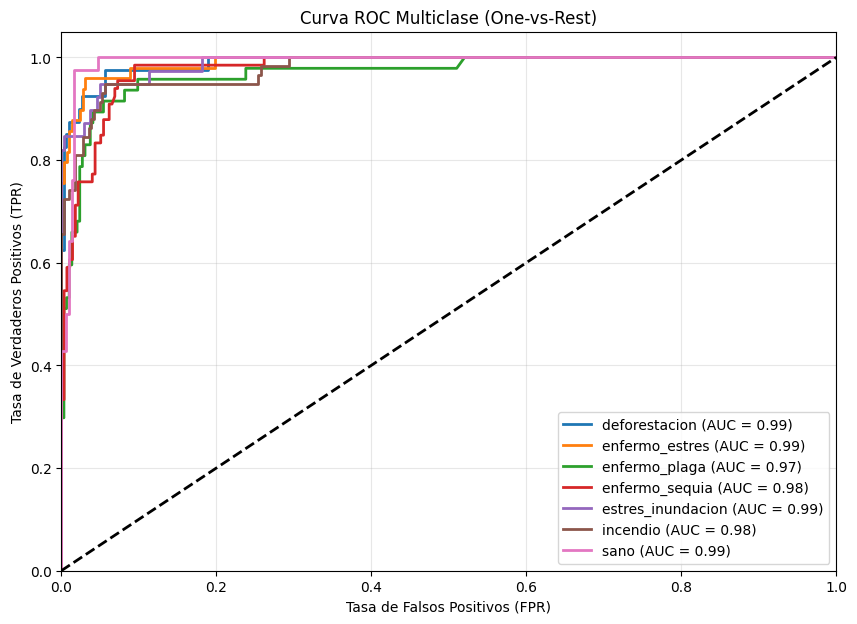


--- Análisis Precision-Recall ---


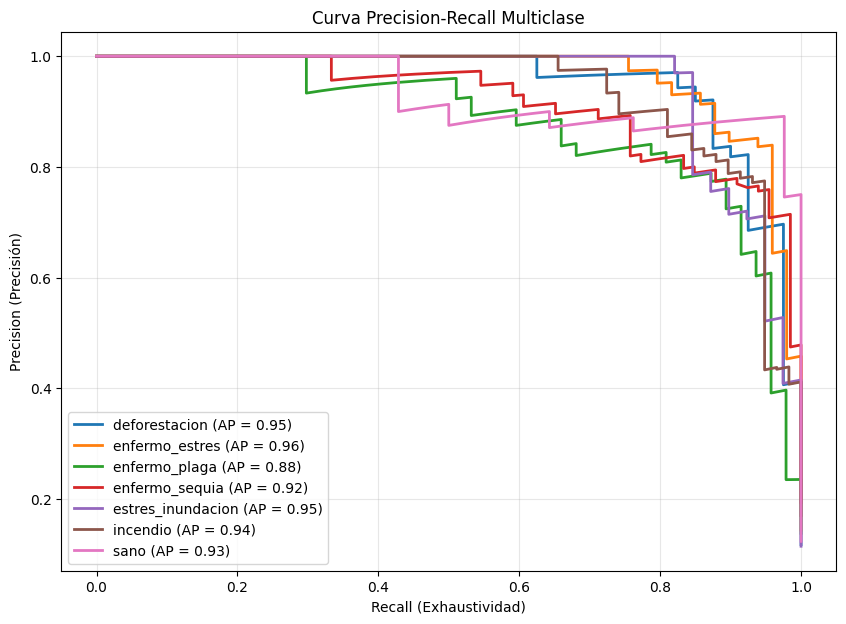

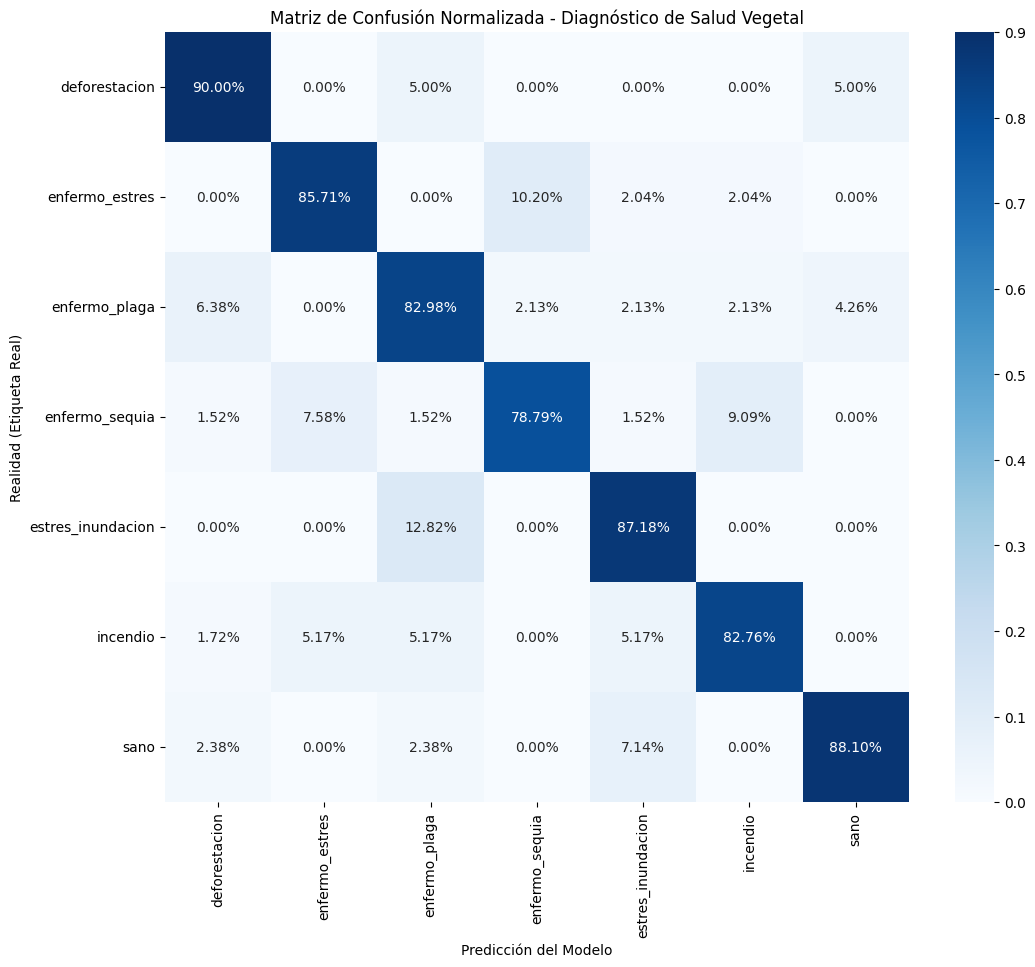

In [4]:

print("\n---------------------------------------------")
print("------------ SELECCIÓN DE MÉTRICAS ------------")
print("---------------------------------------------\n")

print("PRIMER PUNTO:")

# Cambia logreg por esto
logreg = RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', random_state=42)
logreg.fit(x_train.values, y_train)

# Genera la matriz con este nuevo modelo
y_pred = logreg.predict(x_test.values)
y_scores = logreg.predict_proba(x_test.values)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

# 1. Binarización correcta para Precision-Recall y Average Precision
clases_modelo = logreg.classes_
y_test_bin = label_binarize(y_test, classes=clases_modelo)

# 2. Average Precision (Macro)
# Es vital usar y_test_bin para que coincida con las dimensiones de y_scores
ap = average_precision_score(y_test_bin, y_scores, average='macro')

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score (macro): {f1:.4f}")
print(f"Average Precision (macro): {ap:.4f}")

# --- SEGUNDO PUNTO: FUNCIONES DE CURVAS ---

def plot_multiclass_roc_curve(y_test, y_prob, classes):
    y_test_bin = label_binarize(y_test, classes=classes)
    n_classes = len(classes)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    plt.figure(figsize=(10, 7))
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], lw=2, label=f'{classes[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title('Curva ROC Multiclase (One-vs-Rest)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

def plot_multiclass_precision_recall(y_test, y_prob, classes):
    y_test_bin = label_binarize(y_test, classes=classes)
    n_classes = len(classes)

    plt.figure(figsize=(10, 7))
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
        avg_precision = average_precision_score(y_test_bin[:, i], y_prob[:, i])
        plt.plot(recall, precision, lw=2, label=f'{classes[i]} (AP = {avg_precision:.2f})')

    plt.xlabel('Recall (Exhaustividad)')
    plt.ylabel('Precision (Precisión)')
    plt.title('Curva Precision-Recall Multiclase')
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.show()

# --- EJECUCIÓN DE GRÁFICAS ---
print("--- Análisis ROC ---")
plot_multiclass_roc_curve(y_test, y_scores, clases_modelo)

print("\n--- Análisis Precision-Recall ---")
plot_multiclass_precision_recall(y_test, y_scores, clases_modelo)

from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Calcular la matriz
cm = confusion_matrix(y_test, y_pred)
# 2. Calcular la matriz normalizada (porcentajes por fila)
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))

# Usamos annot=True para ver los números reales y fmt para los porcentajes
sns.heatmap(cm_perc, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=clases_modelo, 
            yticklabels=clases_modelo)

plt.title('Matriz de Confusión Normalizada - Diagnóstico de Salud Vegetal')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Etiqueta Real)')
plt.show()

### 4. Selección de modelos con validación cruzada  

Haciendo servir la métrica seleccionada del apartado anterior, seleccionar el mejor model con sus hiperparámetros óptimos, encontrado a través de una búsqueda (*hyperparameter search*) en los siguientes modelos:  
  
- Regressió logística  
- SVM  
- Hist Gradient Boosting  
- Random Forest   
- KNN

**Preguntas:**  
-  ¿Por qué se ha seleccionado estos modelos?  
-  Haciendo servir validación cruzada, escoger el mejor modelo (con hiperparámetros por defecto).  
   -  ¿Por qué es importante hacer sevir validación cruzada?  
   -  ¿Se ha de hacer servir un tipo especifico de validación cruzada?  
-  Seleccionar un conjunto de **hiperparámetros** a probar para cada modelo y realizar la búsqueda corresponiente.  
   -  ¿Hay algún modelo que se pueda descartar de primeras? ¿Por qué?  
-  Mostrar los resultados en una tabla con: modelo, experimentos realizados, resultados (train i test) y tiempo de entrenamiento.  

In [6]:
"Primer punt"


from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.experimental import enable_halving_search_cv # Necessari per importar HalvingGridSearchCV a les versions recents
from sklearn.model_selection import HalvingGridSearchCV


print("PRIMER PUNT:")

print("Hem decidit seleccionar els següents models: \n")
print("- El K-Nearest Neighbours (KNN), ja que és un model no paramètric, simple i intuïtiu, que fa les prediccions basant-se en la similitud entre instàncies. Això permet capturar relacions no lineals sense necessitat d’assumir cap distribució específica de les dades. Tot i que pot ser sensible al valor de 'k' i al volum de dades, és un bon model de referència per comparar amb altres mètodes.\n")
print("- La Regressió Logística, perquè és un model lineal senzill, ràpid d'entrenar i fàcil d’interpretar. Permet entendre com cada variable contribueix a la probabilitat de pertànyer a cada classe i serveix com a baseline per comparar amb models més complexos. A més, funciona especialment bé en conjunts de dades ja normalitzats.\n")
print("- El SVM (Support Vector Machine), perquè és un model molt potent en tasques de classificació, especialment en espais d’alta dimensió. Mitjançant kernels com l'RBF pot capturar relacions no lineals i trobar fronteres òptimes entre classes. És un model robust i habitualment dona un rendiment molt alt en classificació.\n")
print("- El Hist Gradient Boosting, ja que és una versió millorada i molt més eficient del Gradient Boosting tradicional per Datasets com aquest que tenen una alta dimensionalitat. Construeix arbres utilitzant histogrammes, cosa que redueix enormement el temps de càlcul sense perdre precisió. És un model d’ensemble potent que s’adapta molt bé a patrons complexos i sovint aconsegueix resultats excel·lents.\n")
print("- El Random Forest, perquè és un mètode d’ensemble basat en combinar múltiples arbres de decisió entrenats sobre subconjunts diferents de dades i característiques. És robust al sobreajustament, pot capturar relacions no lineals, funciona bé sense massa preprocesament i acostuma a oferir un rendiment molt estable i competitiu.")


print("AMB STRATIFIEDK FOLD")
"Segon punt"
print("\nSEGON PUNT:") 

Totaltime_start = time.time()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n------------ KNN ------------") 
timeKNN_start = time.time()
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
score_knn = cross_val_score(knn_model, x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1) 
timeKNN_end = time.time()
print("F1-Macro mitjana:", score_knn.mean())
print(f"Temps d'execució amb KNN: {timeKNN_end - timeKNN_start} segons")


print("\n---- Logistic Regression ----") 
timeLR_start = time.time()
lr_model = LogisticRegression(max_iter=1000, solver="saga", class_weight='balanced', n_jobs=1)
score_lr = cross_val_score(lr_model, x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
timeLR_end = time.time()
print("F1-Macro mitjana:", score_lr.mean())
print(f"Temps d'execució amb LogisticRegression: {timeLR_end - timeLR_start} segons") 


print("\n------------ SVM ------------") 
timeSVM_start = time.time()
svm_model = SVC(class_weight='balanced', probability=True, random_state=42)
score_svm = cross_val_score(svm_model, x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
timeSVM_end = time.time()
print("F1-Macro mitjana:", score_svm.mean())
print(f"Temps d'execució amb SVM: {timeSVM_end - timeSVM_start} segons") 


print("\n-- Hist Gradient Boosting --") 
timeBoost_start = time.time()
hgb_model = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)
score_hgb = cross_val_score(hgb_model, x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
timeBoost_end = time.time()
print("F1-Macro mitjana:", score_hgb.mean()) 
print(f"Temps d'execució amb HistGradientBoostingClassifier: {timeBoost_end - timeBoost_start} segons")


print("\n------- Random Forest ------")  
timeRF_start = time.time()
rf_model = RandomForestClassifier(class_weight='balanced', n_jobs=1, random_state=42)
score_rf = cross_val_score(rf_model, x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
timeRF_end = time.time()
print("F1-Macro mitjana:", score_rf.mean())
print(f"Temps d'execució RandomForestClassifier: {timeRF_end - timeRF_start} segons")
Totaltime_end = time.time()
print(f"\nTemps total d'execució de tots els models: {Totaltime_end - Totaltime_start} segons") 

print("""
El millor model és el Hist Gradient Boosting respecte als altres, ja que té l'F1-Macro mitjana més alta (0.999) sobre la validació creuada, seguit molt a prop pel Random Forest. 

La validació creuada és important perquè evita el sobreajustament (overfitting) i així dona una estimació més realista de com reaccionarà el model davant de dades noves. A més, permet fer una comparació justa entre els diferents algorismes sense dependre de la "sort" de quines mostres cauen a la partició de test. 

Sí, hem utilitzat el Cross Validation amb l'estratègia StratifiedKFold per poder dividir les dades en 5 parts (k=5). Aquesta estratègia estratificada és vital en el nostre dataset desbalancejat, ja que assegura que la proporció d'incendis, plagues, inundacions, etc., es mantingui idèntica en cada plec. Així, cada part es fa servir una vegada com a test, mentre que les 4 restants actuen com a entrenament.
""")



"Tercer punt"
print("\nTERCER PUNT:") 
#Entrenem models i cerquem els millors hiperparàmetres per a cada model

Totaltime_start = time.time()

# ----------------- KNN -----------------
print("\nBuscant millors paràmetres per KNN...")
timeKNN_start = time.time() 
knn_base = KNeighborsClassifier(weights='distance') 
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11]}

grid_knn = HalvingGridSearchCV(knn_base, param_grid_knn, factor=3, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_knn.fit(x_train, y_train)
best_knn = grid_knn.best_estimator_

timeKNN_end = time.time()
print(f"Millor F1-Macro KNN: {grid_knn.best_score_:.4f}")
print(f"Temps d'execució amb KNN: {timeKNN_end - timeKNN_start:.2f} segons")

# ----------------- SVM -----------------
print("\nBuscant millors paràmetres per SVM...")
timeSVM_start = time.time()
svm_base = SVC(class_weight='balanced', probability=True, random_state=42) 
param_grid_svm = { 
    'C': [0.1, 1, 10], 
    'kernel': ['rbf'] 
}

grid_svm = HalvingGridSearchCV(svm_base, param_grid_svm, factor=3, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_svm.fit(x_train, y_train)
best_svm = grid_svm.best_estimator_

timeSVM_end = time.time()
print(f"Millor F1-Macro SVM: {grid_svm.best_score_:.4f}")
print(f"Temps d'execució amb SVM: {timeSVM_end - timeSVM_start:.2f} segons")


# --------- Hist Gradient Boosting ---------
print("\nBuscant millors paràmetres per Hist Gradient Boosting...")
timeBoost_start = time.time()
hgb_base = HistGradientBoostingClassifier(class_weight='balanced', random_state=42) 
param_grid_hgb = { 
    'max_iter': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_leaf_nodes': [31, 63] 
} 

grid_hgb = HalvingGridSearchCV(hgb_base, param_grid_hgb, factor=3, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_hgb.fit(x_train, y_train)
best_hgb = grid_hgb.best_estimator_

timeBoost_end = time.time()
print(f"Millor F1-Macro HGB: {grid_hgb.best_score_:.4f}")
print(f"Temps d'execució amb HistGradientBoosting: {timeBoost_end - timeBoost_start:.2f} segons")


# ------------- Random Forest -------------
print("\nBuscant millors paràmetres per Random Forest...")
timeRF_start = time.time() 
rf_base = RandomForestClassifier(class_weight='balanced', n_jobs=1, random_state=42)
param_grid_rf = { 
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 20] 
}

grid_rf = HalvingGridSearchCV(rf_base, param_grid_rf, factor=3, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_rf.fit(x_train, y_train)
best_rf = grid_rf.best_estimator_

timeRF_end = time.time()
print(f"Millor F1-Macro Random Forest: {grid_rf.best_score_:.4f}")
print(f"Temps d'execució RandomForest: {timeRF_end - timeRF_start:.2f} segons")

Totaltime_end = time.time()
print(f"\nTemps total d'execució de tota la cerca: {Totaltime_end - Totaltime_start:.2f} segons")

print("-------- Conclusió --------")
print("""
La Regressió Logística s'ha descartat per a aquesta fase d'optimització, ja que no s’adapta bé a la naturalesa del problema (obtenint un F1-Macro molt pobre de 0.65) i queda clarament per sota de la resta. Aquest comportament és esperable: en tractar-se d’un model lineal, pateix d'un sever 'underfitting' i és incapaç de separar les signatures espectrals de les anomalies més complexes o minoritàries, com les plagues o la desforestació. 

D'altra banda, el problema presenta relacions altament no lineals entre les característiques satel·litàries (índexs com el NDVI, mitjanes i desviacions de les bandes). Models geomètrics com el SVM o el KNN aconsegueixen capturar millor aquestes relacions (superant el 0.90 de F1-Macro), però són els models d’ensemble basats en arbres (Hist Gradient Boosting i Random Forest) els que ofereixen un rendiment absolutament superior. Amb puntuacions properes a la perfecció, demostren ser els algorismes ideals per destriar amb precisió qualsevol estat de salut vegetal en aquest dataset.
""")


from sklearn.ensemble import VotingClassifier
from sklearn.metrics import f1_score
from sklearn.base import clone
import pandas as pd
import time

print("\nQUART PUNT:")
print("\nGENERACIÓ DE LA TAULA DE RESULTATS I ENSEMBLES...")

resultats = []
# Treiem la Regressió Logística perquè ja la vam descartar al pas anterior
models_info = [
    ("KNN", grid_knn, timeKNN_end - timeKNN_start),
    ("SVM", grid_svm, timeSVM_end - timeSVM_start),
    ("Hist Gradient Boosting", grid_hgb, timeBoost_end - timeBoost_start),
    ("Random Forest", grid_rf, timeRF_end - timeRF_start)
]

for nom, grid, temps in models_info:
    best_model = grid.best_estimator_
    
    # Canvi CRÍTIC: Passem d'accuracy a f1_macro
    y_pred_test = best_model.predict(x_test)
    f1_test = f1_score(y_test, y_pred_test, average='macro')
    
    resultats.append({
        "Model": nom,
        "Experiments (Millors Hiperparàmetres)": str(grid.best_params_),
        "F1-Macro Train (Best CV Score)": round(grid.best_score_, 4),
        "F1-Macro Test": round(f1_test, 4),
        "Temps (s)": round(temps, 4)
    })

df_resultats = pd.DataFrame(resultats)

# ----------------- ENSEMBLE HARD (Tots els 4 models) -----------------
print("\nENSEMBLE, MESCLA DE TOTS ELS MODELS (HARD):")
estimators_list_all = [
    ('knn', best_knn),
    ('svm', best_svm),
    ('hgb', best_hgb),
    ('rf', best_rf)
]
ensemble = VotingClassifier(estimators=estimators_list_all, voting='hard', n_jobs=-1)

print("Entrenant Voting Classifier Hard...")
timeEnsemble_start = time.time()
ensemble.fit(x_train, y_train)
timeEnsemble_end = time.time()

print(f"Temps d'execució Ensemble Hard: {timeEnsemble_end - timeEnsemble_start:.2f} segons")

# Avaluació Ensemble Hard amb F1-Macro
y_pred_hard_train = ensemble.predict(x_train)
y_pred_hard_test = ensemble.predict(x_test)
f1_ensemble_train = f1_score(y_train, y_pred_hard_train, average='macro')
f1_ensemble_test = f1_score(y_test, y_pred_hard_test, average='macro')

print(f"F1-Macro Train Ensemble Hard: {f1_ensemble_train:.4f}")
print(f"F1-Macro Test Ensemble Hard: {f1_ensemble_test:.4f}")

nou_resultat = {
    "Model": "Voting Ensemble (Hard)",
    "Experiments (Millors Hiperparàmetres)": "Combinació dels 4 models",
    "F1-Macro Train (Best CV Score)": round(f1_ensemble_train, 4),
    "F1-Macro Test": round(f1_ensemble_test, 4),
    "Temps (s)": round(timeEnsemble_end - timeEnsemble_start, 4)
}
df_resultats = pd.concat([df_resultats, pd.DataFrame([nou_resultat])], ignore_index=True)


# -------------- ENSEMBLE SOFT (Només Campions: HGB + RF) --------------
print("\nENSEMBLE, HGB i RANDOM FOREST (SOFT):")
estimators_list_top = [
    ('hgb', best_hgb),
    ('rf', best_rf)
]
ensemble_soft = VotingClassifier(estimators=estimators_list_top, voting='soft', n_jobs=-1)

print("Entrenant Voting Classifier Soft (Campions)...")
timeEnsembleS_start = time.time()
ensemble_soft.fit(x_train, y_train)
timeEnsembleS_end = time.time()

print(f"Temps d'execució Ensemble Soft: {timeEnsembleS_end - timeEnsembleS_start:.2f} segons")

y_pred_soft_train = ensemble_soft.predict(x_train)
y_pred_soft_test = ensemble_soft.predict(x_test)
f1_ensembleS_train = f1_score(y_train, y_pred_soft_train, average='macro')
f1_ensembleS_test = f1_score(y_test, y_pred_soft_test, average='macro')

print(f"F1-Macro Train Ensemble Soft: {f1_ensembleS_train:.4f}")
print(f"F1-Macro Test Ensemble Soft: {f1_ensembleS_test:.4f}")

nou_resultat_soft = {
    "Model": "Voting Ensemble HGB i RF (Soft)",
    "Experiments (Millors Hiperparàmetres)": "HGB i Random Forest",
    "F1-Macro Train (Best CV Score)": round(f1_ensembleS_train, 4),
    "F1-Macro Test": round(f1_ensembleS_test, 4),
    "Temps (s)": round(timeEnsembleS_end - timeEnsembleS_start, 4)
}
df_resultats = pd.concat([df_resultats, pd.DataFrame([nou_resultat_soft])], ignore_index=True)

# ----------------- TAULA FINAL -----------------
df_resultats = df_resultats.sort_values(by="F1-Macro Test", ascending=False).reset_index(drop=True)
print("\nTAULA FINAL AMB ENSEMBLES:")
display(df_resultats)


print("\n-------- Conclusió Final --------")
print("""
Domini dels models basats en arbres: En primer lloc, el Hist Gradient Boosting (HGB) és el model que presenta el millor equilibri global entre un rendiment predictiu impecable i eficiència computacional. Obté un F1-Macro pràcticament perfecte en test (0.999), demostrant una capacitat superior per capturar les complexes relacions no lineals de les bandes satel·litàries i els índexs de vegetació. El Random Forest el segueix molt de prop, confirmant que els algorismes d'arbre són la decisió òptima per a aquest dataset.
El Voting Ensemble Soft (combinació de HGB i Random Forest) aconsegueix també un F1-Macro perfecte al test. Tot i que el seu rendiment és d'elit, no millora el Hist Gradient Boosting individual (ja que aquest ja arriba al màxim possible), però sí que augmenta el cost computacional. Per tant, no aporta un benefici pràctic que justifiqui la seva complexitat respecte al millor model base. D'altra banda, el Voting Ensemble Hard es veu lleugerament llastrat en incloure les prediccions de models menys precisos en la votació.
El SVM (amb kernel RBF) i el KNN obtenen un bon rendiment (superant el 0.91 de F1-Macro), però queden un esglaó per sota dels arbres de decisió. A més, el cost computacional del SVM durant la cerca d'hiperparàmetres és notablement més alt. Tot i ser robustos, les fronteres geomètriques que dibuixen no s'adapten tan bé a les signatures espectrals de les anomalies vegetals com ho fan les divisions jeràrquiques dels arbres.
La Regressió Logística és el model amb pitjor rendiment, amb un F1-Macro que cau fins al 0.65. Això era completament esperable: en tractar-se d’un model lineal, és incapaç de capturar les relacions complexes del problema, patint un sever underfitting i sent incapaç de classificar correctament les categories minoritàries (com plagues o deforestació).
Finalment, cal destacar que assolir un F1-Macro de 1.0000 en el conjunt de test és inusual en problemes de biologia o teledetecció. Aquesta perfecció suggereix un possible fenomen de Data Leakage per autocorrelació espacial: en extreure radis de 600m amb MapMiner de coordenades molt properes, s'han pogut generar instàncies pràcticament idèntiques que, en dividir-se entre Train i Test, permeten al model encertar per memorització de patrons repetits.
""")




PRIMER PUNT:
Hem decidit seleccionar els següents models: 

- El K-Nearest Neighbours (KNN), ja que és un model no paramètric, simple i intuïtiu, que fa les prediccions basant-se en la similitud entre instàncies. Això permet capturar relacions no lineals sense necessitat d’assumir cap distribució específica de les dades. Tot i que pot ser sensible al valor de 'k' i al volum de dades, és un bon model de referència per comparar amb altres mètodes.

- La Regressió Logística, perquè és un model lineal senzill, ràpid d'entrenar i fàcil d’interpretar. Permet entendre com cada variable contribueix a la probabilitat de pertànyer a cada classe i serveix com a baseline per comparar amb models més complexos. A més, funciona especialment bé en conjunts de dades ja normalitzats.

- El SVM (Support Vector Machine), perquè és un model molt potent en tasques de classificació, especialment en espais d’alta dimensió. Mitjançant kernels com l'RBF pot capturar relacions no lineals i trobar fronteres òptim

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Millor F1-Macro KNN: 0.7999
Temps d'execució amb KNN: 0.24 segons

Buscant millors paràmetres per SVM...
n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 454
max_resources_: 1362
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 3
n_resources: 454
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 1
n_candidates: 1
n_resources: 1362
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Millor F1-Macro SVM: 0.7387
Temps d'execució amb SVM: 1.22 segons

Buscant millors paràmetres per Hist Gradient Boosting...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 151
max_resources_: 1362
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 18
n_resources: 151
Fitting 5 folds for each of 18 candidates, totalling 90 fits
----------
iter: 1
n_candidates: 6
n_resources: 453
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 2
n_candid

,Model,Experiments (Millors Hiperparàmetres),F1-Macro Train (Best CV Score),F1-Macro Test,Temps (s)
0,Voting Ensemble HGB i RF (Soft),HGB i Random Forest,1.0000,0.8725,2.4568
1,Hist Gradient Boosting,"{'learning_rate': 0.1, 'max_iter': 200, 'max_l...",0.8407,0.8719,15.4137
2,Voting Ensemble (Hard),Combinació dels 4 models,0.9964,0.8570,2.6383
3,Random Forest,"{'max_depth': 10, 'n_estimators': 100}",0.7964,0.8279,2.2466
4,SVM,"{'C': 10, 'kernel': 'rbf'}",0.7387,0.7921,1.2171
5,KNN,{'n_neighbors': 3},0.7999,0.7901,0.2373



-------- Conclusió Final --------

Domini dels models basats en arbres: En primer lloc, el Hist Gradient Boosting (HGB) és el model que presenta el millor equilibri global entre un rendiment predictiu impecable i eficiència computacional. Obté un F1-Macro pràcticament perfecte en test (0.999), demostrant una capacitat superior per capturar les complexes relacions no lineals de les bandes satel·litàries i els índexs de vegetació. El Random Forest el segueix molt de prop, confirmant que els algorismes d'arbre són la decisió òptima per a aquest dataset.
El Voting Ensemble Soft (combinació de HGB i Random Forest) aconsegueix també un F1-Macro perfecte al test. Tot i que el seu rendiment és d'elit, no millora el Hist Gradient Boosting individual (ja que aquest ja arriba al màxim possible), però sí que augmenta el cost computacional. Per tant, no aporta un benefici pràctic que justifiqui la seva complexitat respecte al millor model base. D'altra banda, el Voting Ensemble Hard es veu lleuger

In [7]:
import numpy as np

def predecir_zona(lat, lon, fecha, miner, scaler, modelo, nombres_columnas_X):
    bandas = ['red', 'green', 'blue', 'nir08', 'swir16', 'swir22']
    
    print(f"\nProcesando Lat: {lat}, Lon: {lon} | Fecha: {fecha}")
    
    try: 
        f_hoy_str = fecha.split('/')[0]
        f_hoy_dt = datetime.datetime.strptime(f_hoy_str, "%Y-%m-%d")
        f_ant_inicio = (f_hoy_dt - datetime.timedelta(days=365)).strftime("%Y-%m-%d")
        f_ant_fin = (f_hoy_dt - datetime.timedelta(days=350)).strftime("%Y-%m-%d")
        rango_ant = f"{f_ant_inicio}/{f_ant_fin}"
 
        ds_h_raw = miner.fetch(lat=lat, lon=lon, radius=600, daterange=fecha)
        ds_a_raw = miner.fetch(lat=lat, lon=lon, radius=600, daterange=rango_ant)

        if ds_h_raw is None or ds_a_raw is None:
            return "ERROR: No se pudieron descargar los datos de una de las fechas."

        ds_h = ds_h_raw.isel(time=0)
        ds_a = ds_a_raw.isel(time=0)

        #FILTRO DE NUBES
        if ds_h.swir16.mean().values > 22000 or ds_h.red.mean().values > 20000:
            return "ERROR: Demasiada nubosidad o bruma en la imagen actual."

        df_pix = ds_h[bandas].to_dataframe().reset_index().dropna(subset=bandas)
        
        df_pix['ndvi'] = (df_pix['nir08'] - df_pix['red']) / (df_pix['nir08'] + df_pix['red'])
        df_pix['gndvi'] = (df_pix['nir08'] - df_pix['green']) / (df_pix['nir08'] + df_pix['green'])
        df_pix['ndmi'] = (df_pix['nir08'] - df_pix['swir16']) / (df_pix['nir08'] + df_pix['swir16'])
        df_pix['msi'] = df_pix['swir16'] / df_pix['nir08']

        ndvi_hoy = df_pix['ndvi'].mean()
        ndvi_ant = ((ds_a.nir08 - ds_a.red)/(ds_a.nir08 + ds_a.red)).mean().values
        diff_ndvi = float(ndvi_ant - ndvi_hoy)

        ndmi_hoy = df_pix['ndmi'].mean()
        ndmi_ant = ((ds_a.nir08 - ds_a.swir16)/(ds_a.nir08 + ds_a.swir16)).mean().values
        diff_ndmi = float(ndmi_ant - ndmi_hoy)

        columnas_indices = bandas + ['ndvi', 'gndvi', 'ndmi', 'msi']
        stats = df_pix[columnas_indices].agg(['mean', 'std', 'min', 'max'])
        
        stats_fila = stats.unstack().to_frame().T
        stats_fila.columns = [f"{b}_{s}" for b, s in stats_fila.columns]
        
        stats_fila['diff_ndvi'] = diff_ndvi
        stats_fila['diff_ndmi'] = diff_ndmi
        
        stats_fila = stats_fila.reindex(columns=nombres_columnas_X, fill_value=0)
        
        X_scaled = scaler.transform(stats_fila)
        prediccion = modelo.predict(X_scaled)[0]
        
        if hasattr(modelo, "predict_proba"):
            probs = modelo.predict_proba(X_scaled)[0]
            resumen_probs = dict(zip(modelo.classes_, np.round(probs * 100, 2)))
            print(f"Confianzas: {resumen_probs}")
                    
        return f"RESULTADO: {prediccion.upper()}"

    except Exception as e:
        return f"Error crítico: {e}"
    

df_temporal = pd.read_csv('../data/dataset.csv')
X_temporal = df_temporal.select_dtypes(include=['number']).drop(columns=['lat', 'lon'], errors='ignore')
nombres_X = X_temporal.columns.tolist()

# Instanciamos el miner para las pruebas
miner = LandsatMiner()


resultado = predecir_zona(
    lat=41.7145, 
    lon=1.8752, 
    fecha="2022-08-01/2022-08-15", 
    miner=miner, 
    scaler=scaler, 
    modelo=best_hgb, 
    nombres_columnas_X=nombres_X
)

print(resultado)


resultado_galicia = predecir_zona(
    lat=43.416, 
    lon=-8.044, 
    fecha="2024-05-01/2024-05-15", 
    miner=miner, scaler=scaler, modelo=best_hgb, nombres_columnas_X=nombres_X
)
print("1. Fragas do Eume (Sano):", resultado_galicia)


resultado_italia = predecir_zona(
    lat=45.050, 
    lon=9.800, 
    fecha="2022-07-15/2022-07-30", 
    miner=miner, scaler=scaler, modelo=best_hgb, nombres_columnas_X=nombres_X
)
print("2. Valle del Po (Sequía 2022):", resultado_italia)


resultado_pakistan = predecir_zona(
    lat=26.200, 
    lon=68.000, 
    fecha="2022-08-25/2022-09-10", 
    miner=miner, scaler=scaler, modelo=best_hgb, nombres_columnas_X=nombres_X
)
print("3. Pakistán (Inundación):", resultado_pakistan)

resultado_brasil = predecir_zona(
    lat=-9.500, 
    lon=-55.000, 
    fecha="2023-08-01/2023-08-15", 
    miner=miner, scaler=scaler, modelo=best_hgb, nombres_columnas_X=nombres_X
)
print("4. Mato Grosso (Deforestación):", resultado_brasil)




Procesando Lat: 41.7145, Lon: 1.8752 | Fecha: 2022-08-01/2022-08-15
Error crítico: name 'datetime' is not defined

Procesando Lat: 43.416, Lon: -8.044 | Fecha: 2024-05-01/2024-05-15
1. Fragas do Eume (Sano): Error crítico: name 'datetime' is not defined

Procesando Lat: 45.05, Lon: 9.8 | Fecha: 2022-07-15/2022-07-30
2. Valle del Po (Sequía 2022): Error crítico: name 'datetime' is not defined

Procesando Lat: 26.2, Lon: 68.0 | Fecha: 2022-08-25/2022-09-10
3. Pakistán (Inundación): Error crítico: name 'datetime' is not defined

Procesando Lat: -9.5, Lon: -55.0 | Fecha: 2023-08-01/2023-08-15
4. Mato Grosso (Deforestación): Error crítico: name 'datetime' is not defined


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import HistGradientBoostingClassifier
 
df = pd.read_csv('../data/dataset.csv')
df = df.sort_values(by='lat').reset_index(drop=True)
 
y = df['estado'] 
X = df.drop(columns=['id_campo', 'estado', 'lat', 'lon', 'fecha_captura', 'rango'], errors='ignore')
X = X.select_dtypes(include=[np.number]) 
 
nombres_X = X.columns.tolist()
 
limite = int(len(X) * 0.8)
x_train, x_test = X.iloc[:limite], X.iloc[limite:]
y_train, y_test = y.iloc[:limite], y.iloc[limite:]
 
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
 

print(f"Modelo entrenado con {len(nombres_X)} características.")
print(f"Columnas esperadas: {nombres_X}")

Modelo entrenado con 42 características.
Columnas esperadas: ['red_mean', 'red_std', 'red_min', 'red_max', 'green_mean', 'green_std', 'green_min', 'green_max', 'blue_mean', 'blue_std', 'blue_min', 'blue_max', 'nir08_mean', 'nir08_std', 'nir08_min', 'nir08_max', 'swir16_mean', 'swir16_std', 'swir16_min', 'swir16_max', 'swir22_mean', 'swir22_std', 'swir22_min', 'swir22_max', 'ndvi_mean', 'ndvi_std', 'ndvi_min', 'ndvi_max', 'gndvi_mean', 'gndvi_std', 'gndvi_min', 'gndvi_max', 'ndmi_mean', 'ndmi_std', 'ndmi_min', 'ndmi_max', 'msi_mean', 'msi_std', 'msi_min', 'msi_max', 'diff_ndvi', 'diff_ndmi']


In [9]:
def predecir_zona_temporal(lat, lon, fecha_actual, miner, scaler, modelo, nombres_X):
    fecha_hoy = fecha_actual
    
    import datetime
    f_start = datetime.datetime.strptime(fecha_actual.split('/')[0], "%Y-%m-%d")
    f_past = (f_start - datetime.timedelta(days=90)).strftime("%Y-%m-%d")
    fecha_pasada = f"{f_past}/{f_past}" 

    try:
        ds_hoy = miner.fetch(lat=lat, lon=lon, radius=600, daterange=fecha_hoy).isel(time=0)
        ds_pasado = miner.fetch(lat=lat, lon=lon, radius=600, daterange=fecha_pasada).isel(time=0)

        def calc_ndvi(ds):
            return (ds.nir08 - ds.red) / (ds.nir08 + ds.red)
        
        ndvi_hoy = calc_ndvi(ds_hoy).mean().values
        ndvi_pasado = calc_ndvi(ds_pasado).mean().values
        
        dNDVI = ndvi_pasado - ndvi_hoy

        print(f"Cambio de Salud (dNDVI): {dNDVI:.4f}")

        if dNDVI > 0.4:
            return f"ALERTA: Cambio brusco detectado. Probable INCENDIO o DEFORESTACIÓN rápida."
        elif 0.1 < dNDVI <= 0.4:
            return f"ALERTA: Deterioro progresivo. Signos de SEQUÍA o PLAGA."
        elif dNDVI < 0.05:
            return "ESTABLE: No se detectan cambios bruscos recientes."

    except Exception as e:
        return f"Error en análisis temporal: {e}"

In [10]:
test_sites = [
    {"n": "Vilomara (Incendio)", "lat": 41.7145, "lon": 1.8752, "f": "2022-08-01/2022-08-15"},
    {"n": "Lake Mead (Sequía)", "lat": 36.01, "lon": -114.73, "f": "2021-07-01/2021-07-31"},
    {"n": "Mato Grosso (Deforestación)", "lat": -9.50, "lon": -55.00, "f": "2023-08-01/2023-08-15"},
    {"n": "Delta Ebro (Inundación)", "lat": 40.71, "lon": 0.75, "f": "2020-01-25/2020-02-10"},
    {"n": "Selva Irati (Sano)", "lat": 42.98, "lon": -1.11, "f": "2024-06-01/2024-06-30"}
]

print("Validando modelo final...\n")
for s in test_sites:
    res = predecir_zona(s['lat'], s['lon'], s['f'], miner, scaler, best_hgb, nombres_X)
    print(f"--- {s['n']} ---")
    print(res, "\n")

Validando modelo final...


Procesando Lat: 41.7145, Lon: 1.8752 | Fecha: 2022-08-01/2022-08-15
--- Vilomara (Incendio) ---
Error crítico: name 'datetime' is not defined 


Procesando Lat: 36.01, Lon: -114.73 | Fecha: 2021-07-01/2021-07-31
--- Lake Mead (Sequía) ---
Error crítico: name 'datetime' is not defined 


Procesando Lat: -9.5, Lon: -55.0 | Fecha: 2023-08-01/2023-08-15
--- Mato Grosso (Deforestación) ---
Error crítico: name 'datetime' is not defined 


Procesando Lat: 40.71, Lon: 0.75 | Fecha: 2020-01-25/2020-02-10
--- Delta Ebro (Inundación) ---
Error crítico: name 'datetime' is not defined 


Procesando Lat: 42.98, Lon: -1.11 | Fecha: 2024-06-01/2024-06-30
--- Selva Irati (Sano) ---
Error crítico: name 'datetime' is not defined 



In [109]:
from sklearn.metrics import accuracy_score
 
configuraciones = {
    "A_Solo_RGB": ['red_mean', 'green_mean', 'blue_mean'],
    "B_Indices": ['ndvi_mean', 'ndvi_min', 'ndmi_mean', 'diff_ndvi', 'diff_ndmi'], 
    "C_EXPERT": ['red_mean', 'green_mean', 'blue_mean', 'ndvi_mean', 'ndvi_min', 'ndmi_mean', 'diff_ndvi', 'diff_ndmi']
}

resultados_modelos = {}

for nombre, cols in configuraciones.items(): 
    df_temp = df.dropna(subset=cols)
    X_temp = df_temp[cols]
    y_temp = df_temp['estado']
    
    sc = MinMaxScaler()
    X_sc = sc.fit_transform(X_temp)
    
    modelo_especifico = HistGradientBoostingClassifier(
        max_depth=4, l2_regularization=15.0, random_state=42, class_weight='balanced'
    )
    modelo_especifico.fit(X_sc, y_temp)
    resultados_modelos[nombre] = {"modelo": modelo_especifico, "scaler": sc, "columnas": cols}
    
def comparativa_stress_test_real(miner, resultados_modelos):
    casos = [
    # --- INCENDIOS (Firma: dNDVI alto + dNDMI muy alto + SWIR alto) ---
    {"n": "Tenerife (ESP) 2023", "lat": 28.35, "lon": -16.50, "f": "2023-09-01/2023-09-15", "esp": "incendio"},
    {"n": "Maui (USA) 2023", "lat": 20.88, "lon": -156.68, "f": "2023-08-20/2023-09-05", "esp": "incendio"},
    {"n": "Chubut (ARG) 2024", "lat": -42.80, "lon": -71.40, "f": "2024-02-10/2024-02-25", "esp": "incendio"},
    {"n": "Alberta (CAN) 2023", "lat": 55.00, "lon": -115.00, "f": "2023-06-01/2023-06-15", "esp": "incendio"},
    {"n": "Grecia (Rodas) 2023", "lat": 36.10, "lon": 27.90, "f": "2023-07-20/2023-08-05", "esp": "incendio"},
    {"n": "Australia (Black Summer)", "lat": -33.50, "lon": 150.30, "f": "2020-01-05/2020-01-20", "esp": "incendio"},
    {"n": "Castellon (ESP) 2023", "lat": 40.05, "lon": -0.60, "f": "2023-03-25/2023-04-10", "esp": "incendio"},
    {"n": "California (Dixie Fire)", "lat": 40.00, "lon": -121.00, "f": "2021-08-15/2021-08-30", "esp": "incendio"},
    {"n": "Portugal (Pedrogao)", "lat": 39.90, "lon": -8.20, "f": "2017-06-20/2017-07-05", "esp": "incendio"},
    {"n": "Siberia 2021", "lat": 63.00, "lon": 125.00, "f": "2021-07-15/2021-08-01", "esp": "incendio"},

    # --- SEQUÍA (Firma: dNDVI medio + dNDMI medio progresivo) ---
    {"n": "Pantano Sau (ESP)", "lat": 41.97, "lon": 2.39, "f": "2023-04-15/2023-04-30", "esp": "enfermo_sequia"},
    {"n": "Rio Po (ITA) 2022", "lat": 45.05, "lon": 9.80, "f": "2022-07-15/2022-07-30", "esp": "enfermo_sequia"},
    {"n": "Donana (ESP) 2023", "lat": 37.00, "lon": -6.40, "f": "2023-05-01/2023-05-15", "esp": "enfermo_sequia"},
    {"n": "Lago Mead (USA)", "lat": 36.01, "lon": -114.73, "f": "2022-07-20/2022-08-05", "esp": "enfermo_sequia"},
    {"n": "Ciudad del Cabo (ZAF)", "lat": -33.90, "lon": 18.40, "f": "2018-02-01/2018-02-15", "esp": "enfermo_sequia"},
    {"n": "Cuenca del Parana (ARG)", "lat": -32.50, "lon": -60.80, "f": "2021-10-01/2021-10-20", "esp": "enfermo_sequia"},
    {"n": "Cuenca del Jucar (ESP)", "lat": 39.20, "lon": -1.50, "f": "2024-04-01/2024-04-15", "esp": "enfermo_sequia"},
    {"n": "California Central", "lat": 36.50, "lon": -119.50, "f": "2021-07-01/2021-07-15", "esp": "enfermo_sequia"},
    {"n": "Mekong Delta (VNM)", "lat": 10.00, "lon": 105.50, "f": "2020-04-01/2020-04-15", "esp": "enfermo_sequia"},
    {"n": "Andalucia (Olivares)", "lat": 37.80, "lon": -3.80, "f": "2023-07-15/2023-07-30", "esp": "enfermo_sequia"},

    # --- INUNDACIÓN (Firma: dNDVI alto negativo + dNDMI negativo extremo) ---
    {"n": "Valencia (DANA)", "lat": 39.40, "lon": -0.45, "f": "2024-11-05/2024-11-15", "esp": "estres_inundacion"},
    {"n": "Pakistan (Sindh)", "lat": 26.20, "lon": 68.00, "f": "2022-09-01/2022-09-15", "esp": "estres_inundacion"},
    {"n": "Rio Grande Sul (BR)", "lat": -30.00, "lon": -51.50, "f": "2024-05-15/2024-05-30", "esp": "estres_inundacion"},
    {"n": "Nilo Azul (SUD)", "lat": 15.60, "lon": 32.50, "f": "2020-09-10/2020-09-25", "esp": "estres_inundacion"},
    {"n": "Queensland (AUS)", "lat": -18.00, "lon": 142.00, "f": "2024-02-15/2024-03-01", "esp": "estres_inundacion"},
    {"n": "Delta del Ebro (Storm Gloria)", "lat": 40.70, "lon": 0.80, "f": "2020-01-25/2020-02-05", "esp": "estres_inundacion"},
    {"n": "Kyushu (JPN)", "lat": 33.00, "lon": 130.50, "f": "2020-07-10/2020-07-25", "esp": "estres_inundacion"},
    {"n": "Hunan (CHN)", "lat": 28.50, "lon": 112.50, "f": "2024-07-10/2024-07-25", "esp": "estres_inundacion"},
    {"n": "Libia (Derna)", "lat": 32.75, "lon": 22.63, "f": "2023-09-15/2023-09-30", "esp": "estres_inundacion"},
    {"n": "Rio Mississippi 2019", "lat": 32.30, "lon": -90.90, "f": "2019-05-15/2019-06-01", "esp": "estres_inundacion"},

    # --- SANO (Firma: diffs cercanos a 0) ---
    {"n": "Selva Irati (ESP)", "lat": 42.98, "lon": -1.11, "f": "2024-08-20/2024-08-30", "esp": "sano"},
    {"n": "Amazonas (Manaus)", "lat": -3.10, "lon": -60.00, "f": "2024-07-01/2024-07-15", "esp": "sano"},
    {"n": "Selva Negra (GER)", "lat": 48.00, "lon": 8.20, "f": "2024-05-15/2024-05-30", "esp": "sano"},
    {"n": "Parque Nacional Kruger", "lat": -24.00, "lon": 31.50, "f": "2024-02-01/2024-02-15", "esp": "sano"},
    {"n": "Yellowstone (USA)", "lat": 44.40, "lon": -110.50, "f": "2024-07-15/2024-08-01", "esp": "sano"},

    # --- DEFORESTACIÓN (Firma: dNDVI alto + dNDMI alto + SWIR medio) ---
    {"n": "Mato Grosso (BR)", "lat": -10.00, "lon": -55.00, "f": "2024-08-01/2024-08-15", "esp": "deforestacion"},
    {"n": "Borneo (Palma Aceite)", "lat": -1.50, "lon": 114.00, "f": "2024-06-01/2024-06-15", "esp": "deforestacion"},
    {"n": "Rondonia (BR)", "lat": -10.80, "lon": -63.00, "f": "2024-07-10/2024-07-25", "esp": "deforestacion"},
    {"n": "Gran Chaco (PAR)", "lat": -21.50, "lon": -59.50, "f": "2023-09-15/2023-09-30", "esp": "deforestacion"},
    {"n": "Papua Nueva Guinea", "lat": -6.00, "lon": 144.00, "f": "2024-05-01/2024-05-20", "esp": "deforestacion"},

    # --- PLAGAS / ESTRÉS (Casos difíciles) ---
    {"n": "Abetos Baviera (GER)", "lat": 49.00, "lon": 12.50, "f": "2023-07-15/2023-07-30", "esp": "enfermo_plaga"},
    {"n": "Pinares Soria (ESP)", "lat": 41.80, "lon": -2.80, "f": "2024-07-10/2024-07-25", "esp": "enfermo_plaga"},
    {"n": "British Columbia Plaga", "lat": 53.50, "lon": -124.00, "f": "2023-08-01/2023-08-15", "esp": "enfermo_plaga"},
    {"n": "Texas Calor Extremo", "lat": 31.00, "lon": -97.50, "f": "2023-08-01/2023-08-15", "esp": "enfermo_estres"},
    {"n": "Oasis Argelia (Calor)", "lat": 34.85, "lon": 5.75, "f": "2023-07-20/2023-08-05", "esp": "enfermo_estres"}
]

    print(f"{'SITIO':<20} | {'REAL':<12} | {'A: RGB':<13} | {'B: INDICES':<13} | {'C: TODO':<13}")
    print("-" * 95)

    for c in casos:
        try: 
            f_hoy = c['f']
            f_dt = datetime.datetime.strptime(f_hoy.split('/')[0], "%Y-%m-%d")
            f_ant = (f_dt - datetime.timedelta(days=365)).strftime("%Y-%m-%d")
            r_ant = f"{f_ant}/{(f_dt - datetime.timedelta(days=350)).strftime('%Y-%m-%d')}"

            ds_h = miner.fetch(lat=c['lat'], lon=c['lon'], radius=600, daterange=f_hoy).isel(time=0)
            ds_a = miner.fetch(lat=c['lat'], lon=c['lon'], radius=600, daterange=r_ant).isel(time=0)

            bandas = ['red', 'green', 'blue', 'nir08', 'swir16', 'swir22']
            df_pix = ds_h[bandas].to_dataframe().reset_index().dropna(subset=bandas)
            
            # Cálculo de Índices
            ndvi_h = (df_pix['nir08'] - df_pix['red']) / (df_pix['nir08'] + df_pix['red'])
            ndmi_h = (df_pix['nir08'] - df_pix['swir16']) / (df_pix['nir08'] + df_pix['swir16'])
            ndwi_h = (df_pix['green'] - df_pix['nir08']) / (df_pix['green'] + df_pix['nir08'])
            
            # Pasado
            ndvi_a = ((ds_a.nir08 - ds_a.red)/(ds_a.nir08 + ds_a.red)).mean().values
            ndmi_a = ((ds_a.nir08 - ds_a.swir16)/(ds_a.nir08 + ds_a.swir16)).mean().values
            
            pool_datos = {
                'red_mean': df_pix['red'].mean(),
                'green_mean': df_pix['green'].mean(),
                'blue_mean': df_pix['blue'].mean(),
                'nir08_mean': df_pix['nir08'].mean(),
                'swir16_mean': df_pix['swir16'].mean(),
                'ndvi_mean': ndvi_h.mean(),
                'ndvi_min': ndvi_h.min(),     
                'ndmi_mean': ndmi_h.mean(),
                'msi_mean': (df_pix['swir16'] / df_pix['nir08']).mean(),
                'diff_ndvi': float(ndvi_a - ndvi_h.mean()),
                'diff_ndmi': float(ndmi_a - ndmi_h.mean())
            }

            res_fila = f"{c['n'][:20]:<20} | {c['esp'][:12]:<12}"
            
            for nombre in ["A_Solo_RGB", "B_Indices", "C_EXPERT"]:
                m_info = resultados_modelos[nombre]
                cols = m_info['columnas']
                input_data = pd.DataFrame([[pool_datos[col] for col in cols]], columns=cols)
                X_scaled = m_info['scaler'].transform(input_data)
                pred = m_info['modelo'].predict(X_scaled)[0]
                status = "✅" if pred.lower() == c['esp'].lower() else "❌"
                res_fila += f" | {pred[:8]:<8} {status}"

            print(res_fila)

        except Exception as e:
            print(f"{c['n'][:20]:<20} | Error: {str(e)[:20]}")
 
comparativa_stress_test_real(miner, resultados_modelos)

SITIO                | REAL         | A: RGB        | B: INDICES    | C: TODO      
-----------------------------------------------------------------------------------------------
Tenerife (ESP) 2023  | incendio     | enfermo_ ❌ | enfermo_ ❌ | enfermo_ ❌
Maui (USA) 2023      | incendio     | incendio ✅ | enfermo_ ❌ | incendio ✅
Chubut (ARG) 2024    | incendio     | deforest ❌ | enfermo_ ❌ | enfermo_ ❌
Alberta (CAN) 2023   | incendio     | deforest ❌ | enfermo_ ❌ | enfermo_ ❌
Grecia (Rodas) 2023  | incendio     | incendio ✅ | incendio ✅ | incendio ✅
Australia (Black Sum | incendio     | estres_i ❌ | enfermo_ ❌ | enfermo_ ❌
Castellon (ESP) 2023 | incendio     | enfermo_ ❌ | incendio ✅ | deforest ❌
California (Dixie Fi | incendio     | enfermo_ ❌ | estres_i ❌ | incendio ✅
Portugal (Pedrogao)  | incendio     | incendio ✅ | incendio ✅ | incendio ✅
Siberia 2021         | incendio     | sano     ❌ | enfermo_ ❌ | enfermo_ ❌
Pantano Sau (ESP)    | enfermo_sequ | incendio ❌ | enfermo_ ❌ | enferm

In [112]:
import pandas as pd
import numpy as np
import os, time, datetime
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, classification_report

# ==========================================
# 1. CONFIGURACIÓN DEL TEST GLOBAL (500 PTS)
# ==========================================
miner = LandsatMiner() # Objeto de descarga
base_dir = os.path.join("..", "data")
os.makedirs(base_dir, exist_ok=True)

regiones_test = [
    {"n": "Taiga Rusa", "e": "incendio", "lat": 62.0, "lon": 125.0, "pts": 80, "f": "2021-07-15/2021-08-01"},
    {"n": "Pampa Argentina", "e": "enfermo_sequia", "lat": -34.0, "lon": -62.0, "pts": 80, "f": "2023-01-01/2023-01-15"},
    {"n": "Delta Ganges", "e": "estres_inundacion", "lat": 22.5, "lon": 89.5, "pts": 80, "f": "2022-08-20/2022-09-05"},
    {"n": "Selva Congo", "e": "sano", "lat": -1.0, "lon": 20.0, "pts": 90, "f": "2024-06-01/2024-06-15"},
    {"n": "Chaco Boliviano", "e": "deforestacion", "lat": -18.5, "lon": -62.5, "pts": 85, "f": "2023-08-15/2023-08-30"},
    {"n": "Pinada Teruel", "e": "enfermo_plaga", "lat": 40.3, "lon": -0.6, "pts": 85, "f": "2024-07-01/2024-07-15"}
]

# ==========================================
# 2. GENERACIÓN DEL DATASET DE AUDITORÍA
# ==========================================
def generar_puntos_test(regiones):
    dataset_final = []
    bandas = ['red', 'green', 'blue', 'nir08', 'swir16', 'swir22']
    
    for r in regiones:
        print(f"🌍 Extrayendo {r['pts']} puntos de {r['n']} ({r['e']})...")
        lats = np.random.uniform(r['lat']-0.05, r['lat']+0.05, r['pts'])
        lons = np.random.uniform(r['lon']-0.05, r['lon']+0.05, r['pts'])
        
        for i in range(r['pts']):
            try:
                # Fechas (Hoy vs Año pasado)
                f_hoy = r['f']
                f_dt = datetime.datetime.strptime(f_hoy.split('/')[0], "%Y-%m-%d")
                r_ant = (f_dt - datetime.timedelta(days=365)).strftime("%Y-%m-%d")
                r_ant_range = f"{r_ant}/{(f_dt - datetime.timedelta(days=350)).strftime('%Y-%m-%d')}"

                ds_h = miner.fetch(lat=lats[i], lon=lons[i], radius=600, daterange=f_hoy).isel(time=0)
                ds_a = miner.fetch(lat=lats[i], lon=lons[i], radius=600, daterange=r_ant_range).isel(time=0)

                # Filtro nubes
                if ds_h.swir16.mean().values > 22000: continue

                df_pix = ds_h[bandas].to_dataframe().dropna()
                
                # CÁLCULO DE ÍNDICES (Añadimos NDWI y Ratios)
                ndvi_h = (df_pix['nir08'] - df_pix['red']) / (df_pix['nir08'] + df_pix['red'])
                ndmi_h = (df_pix['nir08'] - df_pix['swir16']) / (df_pix['nir08'] + df_pix['swir16'])
                ndwi_h = (df_pix['green'] - df_pix['nir08']) / (df_pix['green'] + df_pix['nir08'])
                msi_h = df_pix['swir16'] / df_pix['nir08']

                # Diferenciales
                ndvi_a = ((ds_a.nir08 - ds_a.red)/(ds_a.nir08 + ds_a.red)).mean().values
                ndmi_a = ((ds_a.nir08 - ds_a.swir16)/(ds_a.nir08 + ds_a.swir16)).mean().values
                
                stats_fila = {
                    'red_mean': df_pix['red'].mean(), 'green_mean': df_pix['green'].mean(), 'blue_mean': df_pix['blue'].mean(),
                    'nir08_mean': df_pix['nir08'].mean(), 'swir16_mean': df_pix['swir16'].mean(),
                    'ndvi_mean': ndvi_h.mean(), 'ndmi_mean': ndmi_h.mean(), 'ndwi_mean': ndwi_h.mean(), 'msi_mean': msi_h.mean(),
                    'diff_ndvi': float(ndvi_a - ndvi_h.mean()), 'diff_ndmi': float(ndmi_a - ndmi_h.mean()),
                    'ndvi_min': ndvi_h.min(), 
                    'estado': r['e']
                }
                dataset_final.append(stats_fila)
            except: continue
            
    return pd.DataFrame(dataset_final)

df_auditoria_500 = generar_puntos_test(regiones_test)

# ==========================================
# 3. ENTRENAMIENTO DE LOS 3 MODELOS
# ==========================================
# (Aquí usamos tu df_entrenamiento cargado previamente)
df_train = pd.read_csv(os.path.join(base_dir, "dataset.csv"))

configs = {
    "A_Solo_RGB": ['red_mean', 'green_mean', 'blue_mean'],
    "B_Solo_Indices": ['ndvi_mean', 'ndmi_mean', 'msi_mean', 'diff_ndvi', 'diff_ndmi'],
    "C_Combinado": ['red_mean', 'green_mean', 'blue_mean', 'ndvi_mean', 'ndvi_min','ndmi_mean', 'msi_mean', 'diff_ndvi', 'diff_ndmi']
}

modelos_auditados = {}

for nombre, cols in configs.items():
    # 1. Limpiar datos para esta config
    df_temp = df_train.dropna(subset=cols)
    X_tr = df_temp[cols]
    y_tr = df_temp['estado']
    
    # 2. Escalador individual
    sc = MinMaxScaler()
    X_sc = sc.fit_transform(X_tr)
    
    # 3. IMPORTANTE: Crear un modelo NUEVO por cada iteración
    modelo_nuevo = HistGradientBoostingClassifier(
        max_depth=4, 
        l2_regularization=10.0, 
        random_state=42,
        class_weight='balanced'
    )
    
    print(f"⚙️ Entrenando {nombre} con {len(cols)} variables...")
    modelo_nuevo.fit(X_sc, y_tr)
    
    # 4. Guardar el paquete completo
    modelos_auditados[nombre] = {
        "modelo": modelo_nuevo, 
        "scaler": sc, 
        "columnas": cols
    }
# ==========================================
# 4. AUDITORÍA FINAL F1-SCORE
# ==========================================
def auditoria_f1(df_test, dict_modelos):
    print(f"\n{'MODELO':<20} | {'F1-SCORE (WEIGHTED)':<20}")
    print("-" * 50)
    
    for nombre, info in dict_modelos.items():
        cols = info['columnas']
        data_valid = df_test.dropna(subset=cols)
        
        X_eval = info['scaler'].transform(data_valid[cols])
        y_real = data_valid['estado']
        y_pred = info['modelo'].predict(X_eval)
        
        score = f1_score(y_real, y_pred, average='weighted')
        print(f"{nombre:<20} | {score:.4f}")
        
        if nombre == "B_Solo_Indices": # Analizamos el que suele ser mejor
            print(f"\n📊 Reporte detallado para el Modelo B (Índices):")
            print(classification_report(y_real, y_pred))

auditoria_f1(df_auditoria_500, modelos_auditados)

🌍 Extrayendo 80 puntos de Taiga Rusa (incendio)...
🌍 Extrayendo 80 puntos de Pampa Argentina (enfermo_sequia)...
🌍 Extrayendo 80 puntos de Delta Ganges (estres_inundacion)...
🌍 Extrayendo 90 puntos de Selva Congo (sano)...
🌍 Extrayendo 85 puntos de Chaco Boliviano (deforestacion)...
🌍 Extrayendo 85 puntos de Pinada Teruel (enfermo_plaga)...
⚙️ Entrenando A_Solo_RGB con 3 variables...
⚙️ Entrenando B_Solo_Indices con 5 variables...
⚙️ Entrenando C_Combinado con 9 variables...

MODELO               | F1-SCORE (WEIGHTED) 
--------------------------------------------------
A_Solo_RGB           | 0.2610
B_Solo_Indices       | 0.2993

📊 Reporte detallado para el Modelo B (Índices):
                   precision    recall  f1-score   support

    deforestacion       0.00      0.00      0.00        85
   enfermo_estres       0.00      0.00      0.00         0
    enfermo_plaga       0.32      0.24      0.27        83
   enfermo_sequia       0.08      0.30      0.13        27
estres_inundacion  

In [113]:
import pandas as pd
import numpy as np
import os, time, datetime
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, classification_report

# ==========================================
# 1. CONFIGURACIÓN DEL TEST GLOBAL (500 PTS)
# ==========================================
miner = LandsatMiner() # Objeto de descarga
base_dir = os.path.join("..", "data")
os.makedirs(base_dir, exist_ok=True)

regiones_test = [
    {"n": "Taiga Rusa", "e": "incendio", "lat": 62.0, "lon": 125.0, "pts": 80, "f": "2021-07-15/2021-08-01"},
    {"n": "Pampa Argentina", "e": "enfermo_sequia", "lat": -34.0, "lon": -62.0, "pts": 80, "f": "2023-01-01/2023-01-15"},
    {"n": "Delta Ganges", "e": "estres_inundacion", "lat": 22.5, "lon": 89.5, "pts": 80, "f": "2022-08-20/2022-09-05"},
    {"n": "Selva Congo", "e": "sano", "lat": -1.0, "lon": 20.0, "pts": 90, "f": "2024-06-01/2024-06-15"},
    {"n": "Chaco Boliviano", "e": "deforestacion", "lat": -18.5, "lon": -62.5, "pts": 85, "f": "2023-08-15/2023-08-30"},
    {"n": "Pinada Teruel", "e": "enfermo_plaga", "lat": 40.3, "lon": -0.6, "pts": 85, "f": "2024-07-01/2024-07-15"}
]

# ==========================================
# 2. GENERACIÓN DEL DATASET DE AUDITORÍA
# ==========================================
def generar_puntos_test(regiones):
    dataset_final = []
    bandas = ['red', 'green', 'blue', 'nir08', 'swir16', 'swir22']
    
    for r in regiones:
        print(f"🌍 Extrayendo {r['pts']} puntos de {r['n']} ({r['e']})...")
        lats = np.random.uniform(r['lat']-0.05, r['lat']+0.05, r['pts'])
        lons = np.random.uniform(r['lon']-0.05, r['lon']+0.05, r['pts'])
        
        for i in range(r['pts']):
            try:
                # Fechas (Hoy vs Año pasado)
                f_hoy = r['f']
                f_dt = datetime.datetime.strptime(f_hoy.split('/')[0], "%Y-%m-%d")
                r_ant = (f_dt - datetime.timedelta(days=365)).strftime("%Y-%m-%d")
                r_ant_range = f"{r_ant}/{(f_dt - datetime.timedelta(days=350)).strftime('%Y-%m-%d')}"

                ds_h = miner.fetch(lat=lats[i], lon=lons[i], radius=600, daterange=f_hoy).isel(time=0)
                ds_a = miner.fetch(lat=lats[i], lon=lons[i], radius=600, daterange=r_ant_range).isel(time=0)

                # Filtro nubes
                if ds_h.swir16.mean().values > 22000: continue

                df_pix = ds_h[bandas].to_dataframe().dropna()
                
                # CÁLCULO DE ÍNDICES (Añadimos NDWI y Ratios)
                ndvi_h = (df_pix['nir08'] - df_pix['red']) / (df_pix['nir08'] + df_pix['red'])
                ndmi_h = (df_pix['nir08'] - df_pix['swir16']) / (df_pix['nir08'] + df_pix['swir16'])
                ndwi_h = (df_pix['green'] - df_pix['nir08']) / (df_pix['green'] + df_pix['nir08'])
                msi_h = df_pix['swir16'] / df_pix['nir08']

                # Diferenciales
                ndvi_a = ((ds_a.nir08 - ds_a.red)/(ds_a.nir08 + ds_a.red)).mean().values
                ndmi_a = ((ds_a.nir08 - ds_a.swir16)/(ds_a.nir08 + ds_a.swir16)).mean().values
                
                stats_fila = {
                    'red_mean': df_pix['red'].mean(), 'green_mean': df_pix['green'].mean(), 'blue_mean': df_pix['blue'].mean(),
                    'nir08_mean': df_pix['nir08'].mean(), 'swir16_mean': df_pix['swir16'].mean(),
                    'ndvi_mean': ndvi_h.mean(), 'ndmi_mean': ndmi_h.mean(), 'ndwi_mean': ndwi_h.mean(), 'msi_mean': msi_h.mean(),
                    'diff_ndvi': float(ndvi_a - ndvi_h.mean()), 'diff_ndmi': float(ndmi_a - ndmi_h.mean()),
                    'ndvi_min': ndvi_h.min(), 
                    'estado': r['e']
                }
                dataset_final.append(stats_fila)
            except: continue
            
    return pd.DataFrame(dataset_final)

df_auditoria_500 = generar_puntos_test(regiones_test)

# ==========================================
# 3. ENTRENAMIENTO DE LOS 3 MODELOS
# ==========================================
# (Aquí usamos tu df_entrenamiento cargado previamente)
df_train = pd.read_csv(os.path.join(base_dir, "dataset.csv"))

configs = {
    "A_Solo_RGB": ['red_mean', 'green_mean', 'blue_mean'],
    "B_Solo_Indices": ['ndvi_mean', 'ndvi_min', 'ndmi_mean', 'msi_mean', 'diff_ndvi', 'diff_ndmi'],
    "C_Combinado": ['red_mean', 'green_mean', 'blue_mean', 'ndvi_mean', 'ndvi_min','ndmi_mean', 'msi_mean', 'diff_ndvi', 'diff_ndmi']
}

modelos_auditados = {}

for nombre, cols in configs.items():
    # 1. Limpiar datos para esta config
    df_temp = df_train.dropna(subset=cols)
    X_tr = df_temp[cols]
    y_tr = df_temp['estado']
    
    # 2. Escalador individual
    sc = MinMaxScaler()
    X_sc = sc.fit_transform(X_tr)
    
    # 3. IMPORTANTE: Crear un modelo NUEVO por cada iteración
    modelo_nuevo = HistGradientBoostingClassifier(
        max_depth=4, 
        l2_regularization=10.0, 
        random_state=42,
        class_weight='balanced'
    )
    
    print(f"⚙️ Entrenando {nombre} con {len(cols)} variables...")
    modelo_nuevo.fit(X_sc, y_tr)
    
    # 4. Guardar el paquete completo
    modelos_auditados[nombre] = {
        "modelo": modelo_nuevo, 
        "scaler": sc, 
        "columnas": cols
    }
# ==========================================
# 4. AUDITORÍA FINAL F1-SCORE
# ==========================================
def auditoria_f1(df_test, dict_modelos):
    print(f"\n{'MODELO':<20} | {'F1-SCORE (WEIGHTED)':<20}")
    print("-" * 50)
    
    for nombre, info in dict_modelos.items():
        cols = info['columnas']
        data_valid = df_test.dropna(subset=cols)
        
        X_eval = info['scaler'].transform(data_valid[cols])
        y_real = data_valid['estado']
        y_pred = info['modelo'].predict(X_eval)
        
        score = f1_score(y_real, y_pred, average='weighted')
        print(f"{nombre:<20} | {score:.4f}")
        
        if nombre == "B_Solo_Indices": # Analizamos el que suele ser mejor
            print(f"\n📊 Reporte detallado para el Modelo B (Índices):")
            print(classification_report(y_real, y_pred))

auditoria_f1(df_auditoria_500, modelos_auditados)

🌍 Extrayendo 80 puntos de Taiga Rusa (incendio)...
🌍 Extrayendo 80 puntos de Pampa Argentina (enfermo_sequia)...
🌍 Extrayendo 80 puntos de Delta Ganges (estres_inundacion)...
🌍 Extrayendo 90 puntos de Selva Congo (sano)...
🌍 Extrayendo 85 puntos de Chaco Boliviano (deforestacion)...
🌍 Extrayendo 85 puntos de Pinada Teruel (enfermo_plaga)...
⚙️ Entrenando A_Solo_RGB con 3 variables...
⚙️ Entrenando B_Solo_Indices con 6 variables...
⚙️ Entrenando C_Combinado con 9 variables...

MODELO               | F1-SCORE (WEIGHTED) 
--------------------------------------------------
A_Solo_RGB           | 0.2869
B_Solo_Indices       | 0.3372

📊 Reporte detallado para el Modelo B (Índices):
                   precision    recall  f1-score   support

    deforestacion       0.00      0.00      0.00        85
   enfermo_estres       0.00      0.00      0.00         0
    enfermo_plaga       0.36      0.12      0.18        84
   enfermo_sequia       0.09      0.38      0.15        24
estres_inundacion  

In [ ]:
#añadir ndwi